In [2]:
import matplotlib.pyplot as plt

In [3]:
def read_result_file(file_path):
    with open(file_path, 'r') as f:
        results = f.readlines()

    result_dict = dict()
    k=0
    for l in results:
        l = l.strip()

        if l.startswith('baseline accuracy: '):
            baseline_acc = float(l[-6:])
            if baseline_acc < 0.5:
                baseline_acc = 1 - baseline_acc
            result_dict['baseline_acc'] = baseline_acc
        elif l.startswith('AutoFL-Confidence accuracy: '):
            result_dict['autofl_confidence_acc'] = float(l[-6:])
        elif l.startswith('AutoFL-Confidence roc-auc: '):
            result_dict['autofl_confidence_auc'] = float(l[-6:])
        elif l=='S':
            embedding = 'S'
            result_dict[embedding] = dict()
        elif l=='F':
            embedding = 'F'
            result_dict[embedding] = {}
        elif l=='FA':
            embedding = 'FA'
            result_dict[embedding] = {}
        elif l.startswith('k='):
            k=int(l[2:])
            result_dict[embedding][k] = {}
            # result_dict['baseline_acc'][k] = {'acc': baseline_acc}
        elif l.startswith('Best_mean_accuracy:'):
            result_dict[embedding][k]['acc'] = float(l.split()[-1])
        elif l.startswith('Best mean_roc_auc:'):
            result_dict[embedding][k]['roc_auc'] = float(l.split()[-1])
        elif l.startswith('Best mean_precision:'):
            result_dict[embedding][k]['precision'] = float(l.split()[-1])
        elif l.startswith('Best mean_recall:'):
            result_dict[embedding][k]['recall'] = float(l.split()[-1])
        elif l.startswith('Best mean_npv:'):
            result_dict[embedding][k]['npv'] = float(l.split()[-1])
        elif l.startswith('Best mean_specificity:'):
            result_dict[embedding][k]['spec'] = float(l.split()[-1])
    print(result_dict)
    return result_dict

In [4]:

def draw_graph(data, title, y_data = 'acc', savefig=False, fig_name=None, k=list(range(1, 12)), ylim = None):
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'teal']
    labels = list(data.keys())
    x = k
    print(x)

    if y_data == 'acc':
        if 'baseline_acc' in labels:
            baseline_acc = data['baseline_acc']
            print(baseline_acc)
            plt.plot(x, [baseline_acc] * len(x), linestyle='-', color = colors[-2], label='baseline acc.')
            labels.remove('baseline_acc')
        if 'autofl_confidence_acc' in labels:
            autofl_confidence = data['autofl_confidence_acc']
            plt.plot(x, [autofl_confidence] * len(x), linestyle='-', color = colors[-1], label='autofl_confidence acc.')
            labels.remove('autofl_confidence_acc')

    elif y_data == 'roc_auc':
        if 'autofl_confidence_auc' in labels:
            autofl_confidence_auc = data['autofl_confidence_auc']
            plt.plot(x, [autofl_confidence_auc] * len(x), linestyle='-', color = colors[-1], label='autofl_confidence auc.')
            labels.remove('autofl_confidence_auc')

    
    for i, label in enumerate(labels):
        y = []
        # x = list(data[label].keys())
        print(x)
        print(data[label])
        for k in x:
            y.append(data[label][k][y_data])
        print(label)
        print(x)
        print(y)
        plt.plot(x, y, linestyle='-', color=colors[i], label=label)
    
    plt.title(title)
    plt.xlabel('k')
    plt.ylabel(y_data)

    if ylim is not None:
        plt.ylim(ylim[0], ylim[1])

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'./graphs/{fig_name}')
    plt.show()
    
    

In [5]:

def draw_graph_with_dot_baseline(data, title, y_data = 'acc', savefig=False, fig_name=None, k=list(range(1, 12)), ylim = None):
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'teal']
    labels = sorted(list(data.keys()))
    x = k
    print(x)
    plotted_label = []
    color_idx = 0

    for label in labels:
        if label in plotted_label:
            continue

        if y_data == 'acc' and label.startswith('baseline_acc'):
            baseline_acc = data[label]
            plt.plot(x, [baseline_acc] * len(x), linestyle='--', color = colors[color_idx])
            plotted_label.append(label)
            suffix_label = "_".join(label.split('_')[2:])
            if suffix_label in labels:
                y = []
                for k in x:
                    y.append(data[suffix_label][k][y_data])
                plt.plot(x, y, linestyle='-', color = colors[color_idx], label=suffix_label)
                plotted_label.append(suffix_label)
            color_idx += 1
        # elif '_auc' in label:
        #         pass
        elif not label.startswith('baseline_acc'):
            print(label)
            y = []
            for k in x:
                y.append(data[label][k][y_data])
            plt.plot(x, y, linestyle='-', color=colors[color_idx], label=label)
            plotted_label.append(label)
            color_idx += 1

    
    plt.title(title)
    plt.xlabel('k')
    plt.ylabel(y_data)
    plt.xticks(x)

    if ylim is not None:
        plt.ylim(ylim[0], ylim[1])

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'./graphs/{fig_name}')
    plt.show()
    
    

In [6]:
# # Clustering (FastText), Label criteria 5, raw response
# clustering_sentence_100_raw_95_96_5_file_path = './clustering/fasttext/sentence_vector/100/raw_response/0.95_0.96/label_criteria_5/gcn_result.txt'
# clustering_sentence_100_raw_98_99_5_file_path = './clustering/fasttext/sentence_vector/100/raw_response/0.98_0.99/label_criteria_5/gcn_result.txt'
# clustering_word_100_raw_98_98_5_file_path = './clustering/fasttext/word_vector/100/raw_response/0.98_0.98/label_criteria_5/gcn_result.txt'

# print("clustering_sentence_100_raw_95_96_5 result")
# clustering_sentence_100_raw_95_96_5_result = read_result_file(clustering_sentence_100_raw_95_96_5_file_path)

# print("clustering_sentence_100_raw_98_99_5 result")
# clustering_sentence_100_raw_98_99_5_result = read_result_file(clustering_sentence_100_raw_98_99_5_file_path)

# print("clustering_word_100_raw_98_98_5 result")
# clustering_word_100_raw_98_98_5_result = read_result_file(clustering_word_100_raw_98_98_5_file_path)

In [7]:
# result_dict_for_graph = {}
# result_dict_for_graph['Sentence_100_0.95_0.96'] = clustering_sentence_100_raw_95_96_5_result['FA']
# result_dict_for_graph['Sentence_100_0.98_0.99'] = clustering_sentence_100_raw_98_99_5_result['FA']
# result_dict_for_graph['Word_100_0.98_0.98'] = clustering_word_100_raw_98_98_5_result['FA']
# result_dict_for_graph['baseline_acc'] = clustering_word_100_raw_98_98_5_result['baseline_acc']

# draw_graph(result_dict_for_graph, 'Accuracy(Clustering, Label_criteria=5)', fig_name = 'Accuracy_clustering_label_criteria_5', y_data='acc', k=[5, 10, 15, 20, 25, 30, 35, 40], ylim=[0.9, 1])

Label criteria: 1
{'baseline_acc': 0.7739, 'FA': {5: {'acc': 0.774, 'roc_auc': 0.5048, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 10: {'acc': 0.774, 'roc_auc': 0.4866, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 15: {'acc': 0.774, 'roc_auc': 0.4684, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 20: {'acc': 0.774, 'roc_auc': 0.4434, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 25: {'acc': 0.774, 'roc_auc': 0.468, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 30: {'acc': 0.774, 'roc_auc': 0.4343, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 35: {'acc': 0.774, 'roc_auc': 0.4444, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 40: {'acc': 0.774, 'roc_auc': 0.4883, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}}}
Label criteria: 2
{'baseline_acc': 0.8564, 'FA': {5: {'acc': 0.8564, 'roc_auc': 0.4842, 'precision': 0.0, 'recall': 0.0, 'npv': 0.8564, 'spec': 1.0}, 10: {'acc

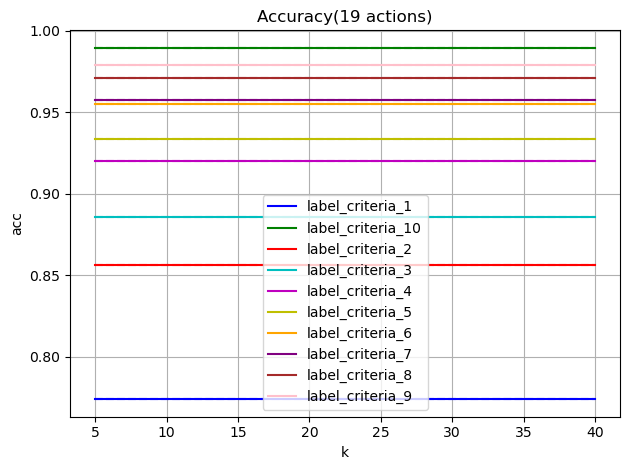

[5, 10, 15, 20, 25, 30, 35, 40]
label_criteria_1
label_criteria_10
label_criteria_2
label_criteria_3
label_criteria_4
label_criteria_5
label_criteria_6
label_criteria_7
label_criteria_8
label_criteria_9


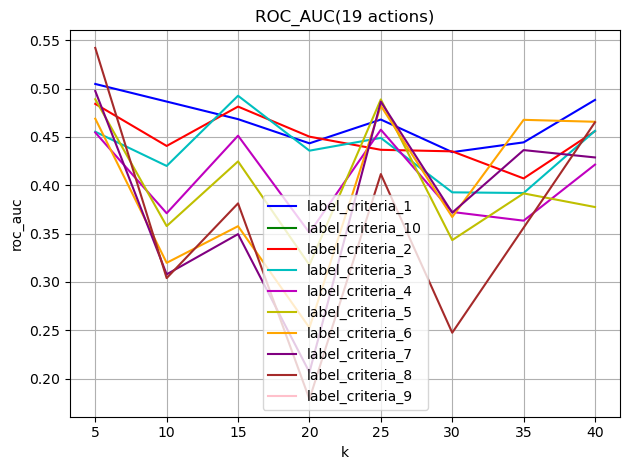

In [8]:
# Only action, embedding_length=20, processed_response
result_dict_for_graph = {}

for i in range(1, 11):
    file_path = f'./only_action/20/processed_response/label_criteria_{i}/gcn_result.txt'
    print(f"Label criteria: {i}")
    result = read_result_file(file_path)
    result_dict_for_graph[f'label_criteria_{i}'] = result['FA']
    result_dict_for_graph[f'baseline_acc_label_criteria_{i}'] = result['baseline_acc']
    
draw_graph_with_dot_baseline(result_dict_for_graph, 'Accuracy(19 actions)', fig_name = 'only_action_20_processed_response.png', y_data='acc', k=[5, 10, 15, 20, 25, 30, 35, 40])
draw_graph_with_dot_baseline(result_dict_for_graph, 'ROC_AUC(19 actions)', fig_name = 'only_action_20_processed_response.png', y_data='roc_auc', k=[5, 10, 15, 20, 25, 30, 35, 40])

Label criteria: 1
{'baseline_acc': 0.7739, 'FA': {5: {'acc': 0.774, 'roc_auc': 0.5238, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 10: {'acc': 0.774, 'roc_auc': 0.507, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 15: {'acc': 0.774, 'roc_auc': 0.4227, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 20: {'acc': 0.774, 'roc_auc': 0.4894, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 25: {'acc': 0.7767, 'roc_auc': 0.6823, 'precision': 0.2, 'recall': 0.0125, 'npv': 0.7761, 'spec': 1.0}, 30: {'acc': 0.774, 'roc_auc': 0.6946, 'precision': 0.2667, 'recall': 0.0243, 'npv': 0.7771, 'spec': 0.9932}, 35: {'acc': 0.774, 'roc_auc': 0.5088, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 40: {'acc': 0.774, 'roc_auc': 0.4311, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}}}
Label criteria: 2
{'baseline_acc': 0.8564, 'FA': {5: {'acc': 0.8564, 'roc_auc': 0.4746, 'precision': 0.0, 'recall': 0.0, 'npv': 0.8564, 'spec': 

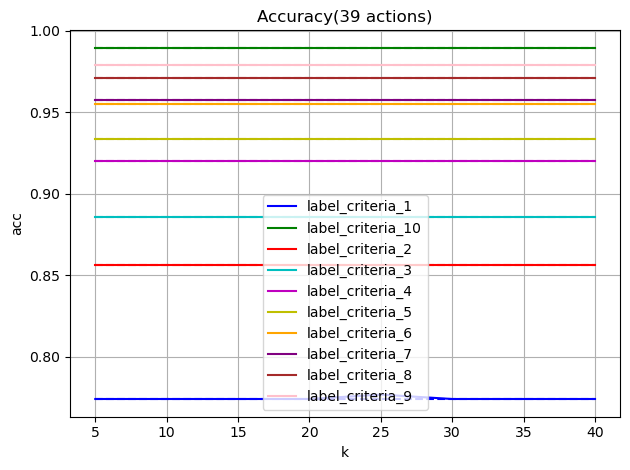

[5, 10, 15, 20, 25, 30, 35, 40]
label_criteria_1
label_criteria_10
label_criteria_2
label_criteria_3
label_criteria_4
label_criteria_5
label_criteria_6
label_criteria_7
label_criteria_8
label_criteria_9


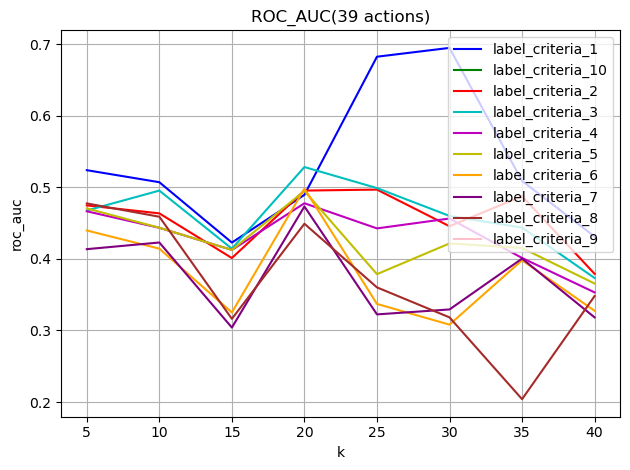

In [9]:
# Only action, embedding_length=40, processed_response
result_dict_for_graph = {}

for i in range(1, 11):
    file_path = f'./only_action/40/processed_response/label_criteria_{i}/gcn_result.txt'
    print(f"Label criteria: {i}")
    result = read_result_file(file_path)
    result_dict_for_graph[f'label_criteria_{i}'] = result['FA']
    result_dict_for_graph[f'baseline_acc_label_criteria_{i}'] = result['baseline_acc']
    
draw_graph_with_dot_baseline(result_dict_for_graph, 'Accuracy(39 actions)', fig_name = 'only_action_20_processed_response.png', y_data='acc', k=[5, 10, 15, 20, 25, 30, 35, 40])
draw_graph_with_dot_baseline(result_dict_for_graph, 'ROC_AUC(39 actions)', fig_name = 'only_action_20_processed_response.png', y_data='roc_auc', k=[5, 10, 15, 20, 25, 30, 35, 40])

Label criteria: 1
{'baseline_acc': 0.7739, 'FA': {5: {'acc': 0.774, 'roc_auc': 0.5073, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 10: {'acc': 0.774, 'roc_auc': 0.5625, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 15: {'acc': 0.7767, 'roc_auc': 0.6221, 'precision': 0.2, 'recall': 0.0133, 'npv': 0.7762, 'spec': 1.0}, 20: {'acc': 0.7767, 'roc_auc': 0.6327, 'precision': 0.2, 'recall': 0.0133, 'npv': 0.7762, 'spec': 1.0}, 25: {'acc': 0.7767, 'roc_auc': 0.6525, 'precision': 0.2, 'recall': 0.0133, 'npv': 0.7762, 'spec': 1.0}, 30: {'acc': 0.7767, 'roc_auc': 0.6212, 'precision': 0.2, 'recall': 0.0133, 'npv': 0.7762, 'spec': 1.0}, 35: {'acc': 0.774, 'roc_auc': 0.4125, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 40: {'acc': 0.774, 'roc_auc': 0.4453, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}}}
Label criteria: 2
{'baseline_acc': 0.8564, 'FA': {5: {'acc': 0.8564, 'roc_auc': 0.476, 'precision': 0.0, 'recall': 0.0, 'npv': 0.8564, 'sp

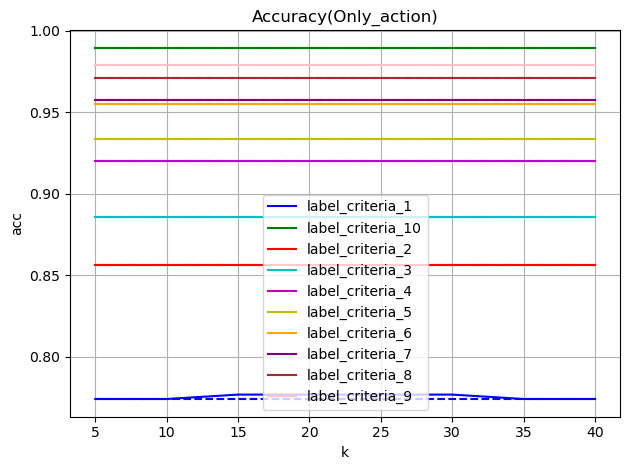

[5, 10, 15, 20, 25, 30, 35, 40]
label_criteria_1
label_criteria_10
label_criteria_2
label_criteria_3
label_criteria_4
label_criteria_5
label_criteria_6
label_criteria_7
label_criteria_8
label_criteria_9


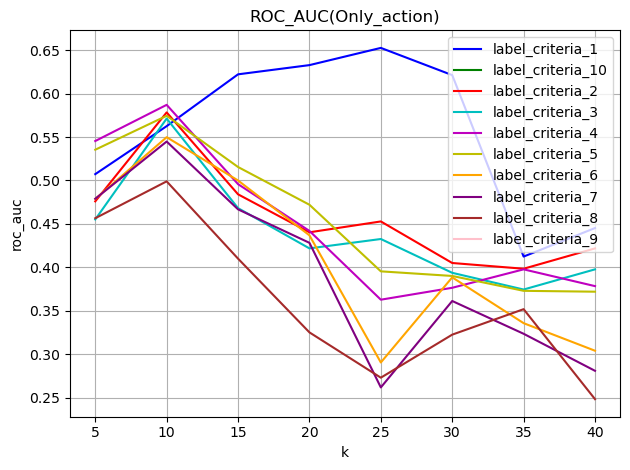

In [10]:
# Clustering, sentence_vector, embedding_length=100, processed_response, 0.96_0.97
result_dict_for_graph = {}

for i in range(1, 11):
    file_path = f'./clustering/fasttext/sentence_vector/100/processed_response/0.96_0.97/label_criteria_{i}/gcn_result.txt'
    print(f"Label criteria: {i}")
    result = read_result_file(file_path)
    result_dict_for_graph[f'label_criteria_{i}'] = result['FA']
    result_dict_for_graph[f'baseline_acc_label_criteria_{i}'] = result['baseline_acc']
    
draw_graph_with_dot_baseline(result_dict_for_graph, 'Accuracy(Only_action)', fig_name = 'only_action_20_processed_response.png', y_data='acc', k=[5, 10, 15, 20, 25, 30, 35, 40])
draw_graph_with_dot_baseline(result_dict_for_graph, 'ROC_AUC(Only_action)', fig_name = 'only_action_20_processed_response.png', y_data='roc_auc', k=[5, 10, 15, 20, 25, 30, 35, 40])

Label criteria: 1
{'baseline_acc': 0.7739, 'FA': {5: {'acc': 0.774, 'roc_auc': 0.4677, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 10: {'acc': 0.774, 'roc_auc': 0.4467, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 15: {'acc': 0.774, 'roc_auc': 0.4214, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 20: {'acc': 0.774, 'roc_auc': 0.4667, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 25: {'acc': 0.774, 'roc_auc': 0.5104, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 30: {'acc': 0.774, 'roc_auc': 0.5094, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 35: {'acc': 0.774, 'roc_auc': 0.5131, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}, 40: {'acc': 0.774, 'roc_auc': 0.5351, 'precision': 0.0, 'recall': 0.0, 'npv': 0.774, 'spec': 1.0}}}
Label criteria: 2
{'baseline_acc': 0.8564, 'FA': {5: {'acc': 0.8564, 'roc_auc': 0.47, 'precision': 0.0, 'recall': 0.0, 'npv': 0.8564, 'spec': 1.0}, 10: {'acc'

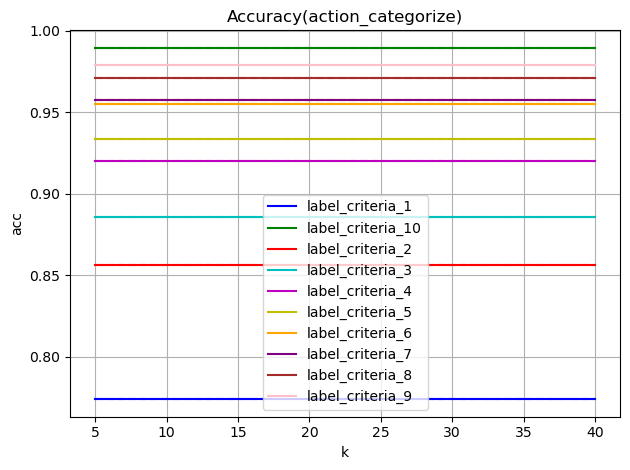

[5, 10, 15, 20, 25, 30, 35, 40]
label_criteria_1
label_criteria_10
label_criteria_2
label_criteria_3
label_criteria_4
label_criteria_5
label_criteria_6
label_criteria_7
label_criteria_8
label_criteria_9


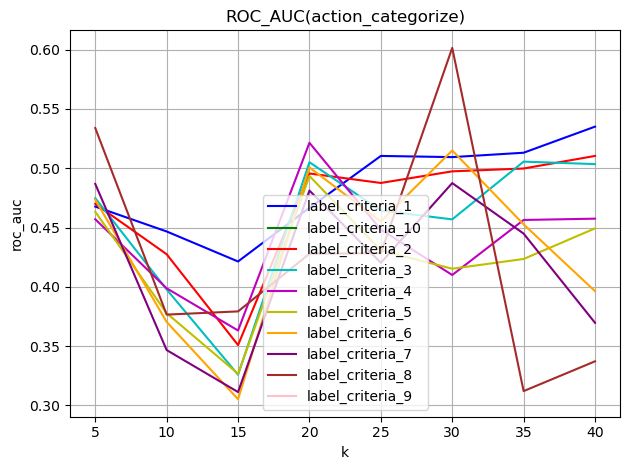

In [11]:
# Only_action, categorize, processed_response
result_dict_for_graph = {}

for i in range(1, 11):
    file_path = f'./only_action/categorize/processed_response/label_criteria_{i}/gcn_result.txt'
    print(f"Label criteria: {i}")
    result = read_result_file(file_path)
    result_dict_for_graph[f'label_criteria_{i}'] = result['FA']
    result_dict_for_graph[f'baseline_acc_label_criteria_{i}'] = result['baseline_acc']
    
draw_graph_with_dot_baseline(result_dict_for_graph, 'Accuracy(action_categorize)', fig_name = 'only_action_categorize_processed_response.png', y_data='acc', k=[5, 10, 15, 20, 25, 30, 35, 40])
draw_graph_with_dot_baseline(result_dict_for_graph, 'ROC_AUC(action_categorize)', fig_name = 'only_action_categorize_processed_response.png', y_data='roc_auc', k=[5, 10, 15, 20, 25, 30, 35, 40])

Label criteria: 1
{'baseline_acc': 0.6649, 'FA': {5: {'acc': 0.6649, 'roc_auc': 0.4953, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6649, 'spec': 1.0}, 10: {'acc': 0.6915, 'roc_auc': 0.6598, 'precision': 0.6876, 'recall': 0.1571, 'npv': 0.6937, 'spec': 0.9601}, 15: {'acc': 0.7154, 'roc_auc': 0.7099, 'precision': 0.6533, 'recall': 0.3258, 'npv': 0.7292, 'spec': 0.9127}, 20: {'acc': 0.7155, 'roc_auc': 0.7386, 'precision': 0.6605, 'recall': 0.2984, 'npv': 0.7244, 'spec': 0.925}, 25: {'acc': 0.7101, 'roc_auc': 0.7233, 'precision': 0.6567, 'recall': 0.242, 'npv': 0.7135, 'spec': 0.9441}, 30: {'acc': 0.6914, 'roc_auc': 0.7336, 'precision': 0.6427, 'recall': 0.2349, 'npv': 0.7056, 'spec': 0.9256}, 35: {'acc': 0.7045, 'roc_auc': 0.7288, 'precision': 0.6134, 'recall': 0.3521, 'npv': 0.7333, 'spec': 0.8858}, 40: {'acc': 0.6967, 'roc_auc': 0.7184, 'precision': 0.5971, 'recall': 0.3302, 'npv': 0.7238, 'spec': 0.8852}}}
Label criteria: 2
{'baseline_acc': 0.7234, 'FA': {5: {'acc': 0.7234, 'roc_auc': 0

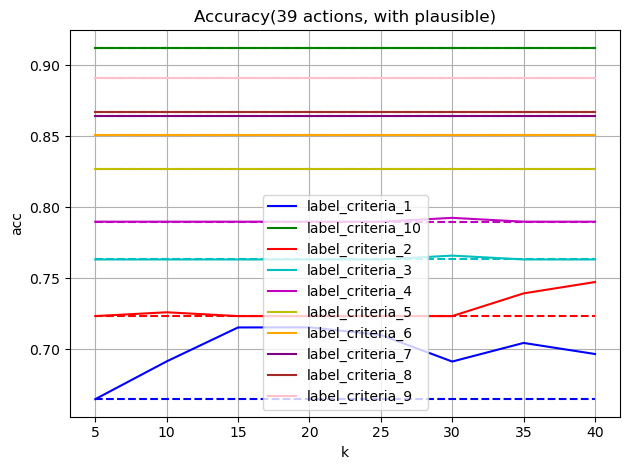

[5, 10, 15, 20, 25, 30, 35, 40]
label_criteria_1
label_criteria_10
label_criteria_2
label_criteria_3
label_criteria_4
label_criteria_5
label_criteria_6
label_criteria_7
label_criteria_8
label_criteria_9


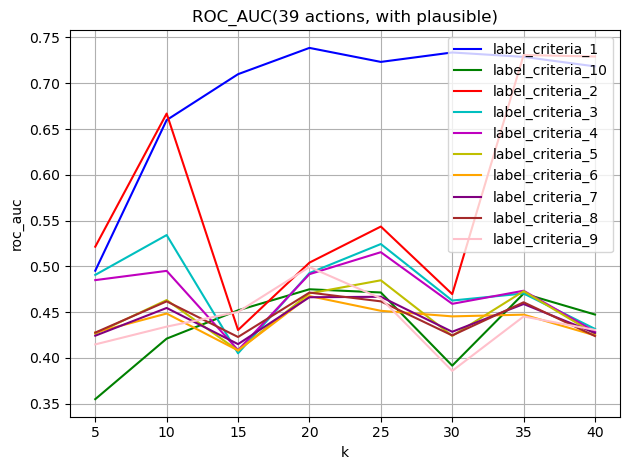

In [12]:
# Only action, embedding_length=40, processed_response, plausible_patch
result_dict_for_graph = {}

for i in range(1, 11):
    file_path = f'./only_action/40/processed_response/plausible_patch/label_criteria_{i}/gcn_result.txt'
    print(f"Label criteria: {i}")
    result = read_result_file(file_path)
    result_dict_for_graph[f'label_criteria_{i}'] = result['FA']
    result_dict_for_graph[f'baseline_acc_label_criteria_{i}'] = result['baseline_acc']
    
draw_graph_with_dot_baseline(result_dict_for_graph, 'Accuracy(39 actions, with plausible)', fig_name = 'only_action_40_processed_plausible_response.png', y_data='acc', k=[5, 10, 15, 20, 25, 30, 35, 40])
draw_graph_with_dot_baseline(result_dict_for_graph, 'ROC_AUC(39 actions, with plausible)', fig_name = 'only_action_20_processed__plausible_response.png', y_data='roc_auc', k=[5, 10, 15, 20, 25, 30, 35, 40])

Label criteria: 1
{'baseline_acc': 0.6649, 'FA': {5: {'acc': 0.6649, 'roc_auc': 0.4953, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6649, 'spec': 1.0}, 10: {'acc': 0.6915, 'roc_auc': 0.6598, 'precision': 0.6876, 'recall': 0.1571, 'npv': 0.6937, 'spec': 0.9601}, 15: {'acc': 0.7154, 'roc_auc': 0.7099, 'precision': 0.6533, 'recall': 0.3258, 'npv': 0.7292, 'spec': 0.9127}, 20: {'acc': 0.7155, 'roc_auc': 0.7386, 'precision': 0.6605, 'recall': 0.2984, 'npv': 0.7244, 'spec': 0.925}, 25: {'acc': 0.7101, 'roc_auc': 0.7233, 'precision': 0.6567, 'recall': 0.242, 'npv': 0.7135, 'spec': 0.9441}, 30: {'acc': 0.6914, 'roc_auc': 0.7336, 'precision': 0.6427, 'recall': 0.2349, 'npv': 0.7056, 'spec': 0.9256}, 35: {'acc': 0.7045, 'roc_auc': 0.7288, 'precision': 0.6134, 'recall': 0.3521, 'npv': 0.7333, 'spec': 0.8858}, 40: {'acc': 0.6967, 'roc_auc': 0.7184, 'precision': 0.5971, 'recall': 0.3302, 'npv': 0.7238, 'spec': 0.8852}}}
Label criteria: 2
{'baseline_acc': 0.7234, 'FA': {5: {'acc': 0.7234, 'roc_auc': 0

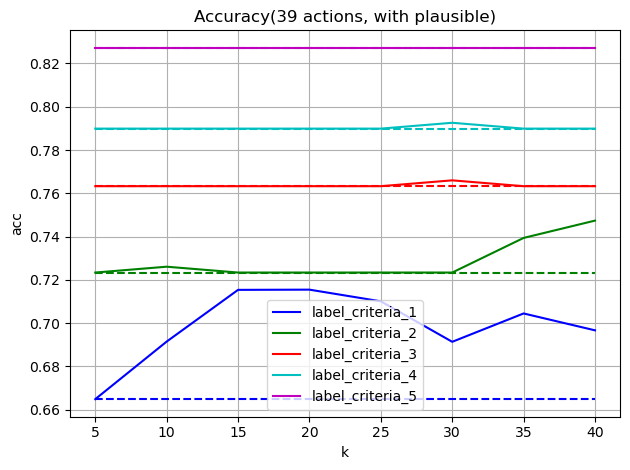

[5, 10, 15, 20, 25, 30, 35, 40]
label_criteria_1
label_criteria_2
label_criteria_3
label_criteria_4
label_criteria_5


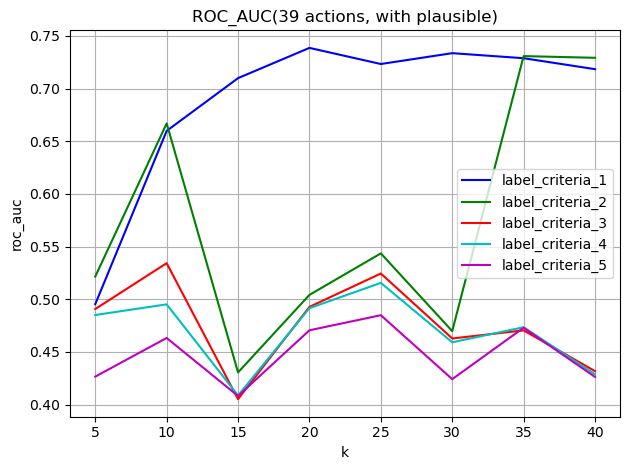

In [ ]:
# Only action, embedding_length=40, processed_response, plausible_patch
result_dict_for_graph = {}

for i in range(1, 6):
    file_path = f'./only_action/40/processed_response/plausible_patch/label_criteria_{i}/gcn_result.txt'
    print(f"Label criteria: {i}")
    result = read_result_file(file_path)
    result_dict_for_graph[f'label_criteria_{i}'] = result['FA']
    result_dict_for_graph[f'baseline_acc_label_criteria_{i}'] = result['baseline_acc']
    
draw_graph_with_dot_baseline(result_dict_for_graph, 'Accuracy(39 actions, with plausible)', fig_name = 'only_action_40_processed_plausible_response.png', y_data='acc', k=[5, 10, 15, 20, 25, 30, 35, 40])
draw_graph_with_dot_baseline(result_dict_for_graph, 'ROC_AUC(39 actions, with plausible)', fig_name = 'only_action_20_processed__plausible_response.png', y_data='roc_auc', k=[5, 10, 15, 20, 25, 30, 35, 40])

Label criteria: 1
{'baseline_acc': 0.6649, 'FA': {5: {'acc': 0.6649, 'roc_auc': 0.4445, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6649, 'spec': 1.0}, 10: {'acc': 0.6994, 'roc_auc': 0.6485, 'precision': 0.6295, 'recall': 0.2611, 'npv': 0.7124, 'spec': 0.9202}, 15: {'acc': 0.7234, 'roc_auc': 0.7073, 'precision': 0.6116, 'recall': 0.4875, 'npv': 0.767, 'spec': 0.8391}, 20: {'acc': 0.7341, 'roc_auc': 0.7333, 'precision': 0.6244, 'recall': 0.5237, 'npv': 0.7799, 'spec': 0.8393}, 25: {'acc': 0.7208, 'roc_auc': 0.7215, 'precision': 0.5918, 'recall': 0.5548, 'npv': 0.7829, 'spec': 0.8021}, 30: {'acc': 0.7181, 'roc_auc': 0.7266, 'precision': 0.6059, 'recall': 0.4482, 'npv': 0.7564, 'spec': 0.8567}, 35: {'acc': 0.7286, 'roc_auc': 0.7435, 'precision': 0.603, 'recall': 0.5234, 'npv': 0.7811, 'spec': 0.8365}, 40: {'acc': 0.7366, 'roc_auc': 0.7485, 'precision': 0.6228, 'recall': 0.5688, 'npv': 0.7914, 'spec': 0.8242}}}
Label criteria: 2
{'baseline_acc': 0.7234, 'FA': {5: {'acc': 0.7234, 'roc_auc': 0

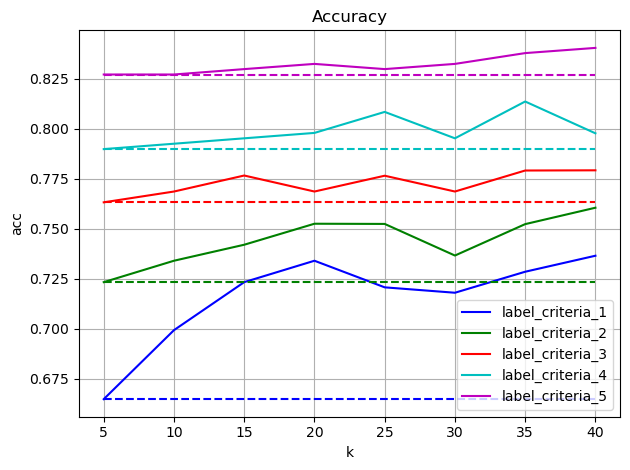

[5, 10, 15, 20, 25, 30, 35, 40]
label_criteria_1
label_criteria_2
label_criteria_3
label_criteria_4
label_criteria_5


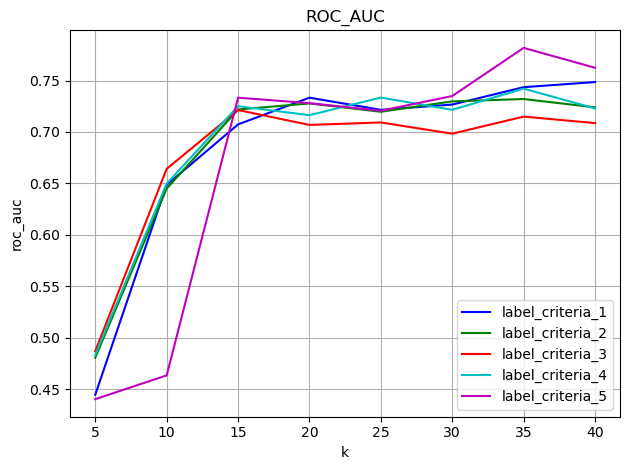

In [15]:
# Only action, embedding_length=40, processed_response, plausible_patch, bigger_model
result_dict_for_graph = {}

for i in range(1, 6):
    file_path = f'./bigger_model/only_action/40/processed_response/plausible_patch/label_criteria_{i}/gcn_result.txt'
    print(f"Label criteria: {i}")
    result = read_result_file(file_path)
    result_dict_for_graph[f'label_criteria_{i}'] = result['FA']
    result_dict_for_graph[f'baseline_acc_label_criteria_{i}'] = result['baseline_acc']
    
draw_graph_with_dot_baseline(result_dict_for_graph, 'Accuracy', fig_name = 'only_action_40_processed_plausible_response_bigger.png', y_data='acc', k=[5, 10, 15, 20, 25, 30, 35, 40])
draw_graph_with_dot_baseline(result_dict_for_graph, 'ROC_AUC', fig_name = 'only_action_20_processed__plausible_response_bigger.png', y_data='roc_auc', k=[5, 10, 15, 20, 25, 30, 35, 40])